# Training Transformer

### Description
In this assignment, we are tasked with utilizing a transformer decoder-only architecture for pretraining, with a focus on next-token prediction, applied to Pokémon images. Specifically, in testing, if given 60% of an image, predict the remaining part.

Please feel free to mail me if you have any questions.

# Utilities

### Download packages

In [3]:
!uv add datasets==4.0.0

Resolved 190 packages in 386ms                                       
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/143.30 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)------------------- 48.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)2m----------------- 64.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)m-------------- 80.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)---------- 96.00 KiB/143.30 KiB        
⠙ Preparing packages... (0/1)---------- 112.00 KiB/143.30 KiB       
⠙ Preparing packages... (0/1)---------- 128.00 KiB/143.30 KiB       
⠙ Preparing packages... (0/1)---------- 143.30 KiB/143.30 KiB       
Prepared 1 package in 50ms                                                        
Uninstalled 4 packages in 

### Import Packages

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModelForCausalLM, GPT2Config, set_seed
from datasets import load_dataset
from typing import Dict, Any, Optional

### Check Devices

In [5]:
# !nvidia-smi

### Set Random Seed

In [2]:
set_seed(0)

# Prepare Data

### Define Dataset

In [3]:
from typing import List, Tuple, Union
import torch
from torch.utils.data import Dataset

class PixelSequenceDataset(Dataset):
    def __init__(self, data: List[List[int]], mode: str = "train"):
        """
        A dataset class for handling pixel sequences.

        Args:
            data (List[List[int]]): A list of sequences, where each sequence is a list of integers.
            mode (str): The mode of operation, either "train", "dev", or "test".
                - "train": Returns (input_ids, labels) where input_ids are sequence[:-1] and labels are sequence[1:].
                - "dev": Returns (input_ids, labels) where input_ids are sequence[:-160] and labels are sequence[-160:].
                - "test": Returns only input_ids, as labels are not available.
        """
        self.data = data
        self.mode = mode

    def __len__(self) -> int:
        """Returns the total number of sequences in the dataset."""
        return len(self.data)

    def __getitem__(self, idx: int) -> Union[Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        """
        Fetches a sequence from the dataset and processes it based on the mode.

        Args:
            idx (int): The index of the sequence.

        Returns:
            - If mode == "train": Tuple[torch.Tensor, torch.Tensor] -> (input_ids, labels)
            - If mode == "dev": Tuple[torch.Tensor, torch.Tensor] -> (input_ids, labels)
            - If mode == "test": torch.Tensor -> input_ids
        """
        sequence = self.data[idx]

        if self.mode == "train":
            input_ids = torch.tensor(sequence[:-1], dtype=torch.long)
            labels = torch.tensor(sequence[1:], dtype=torch.long)
            return input_ids, labels

        elif self.mode == "dev":
            input_ids = torch.tensor(sequence[:-160], dtype=torch.long)
            labels = torch.tensor(sequence[-160:], dtype=torch.long)
            return input_ids, labels

        elif self.mode == "test":
            input_ids = torch.tensor(sequence, dtype=torch.long)
            return input_ids

        raise ValueError(f"Invalid mode: {self.mode}. Choose from 'train', 'dev', or 'test'.")

### Download Dataset & Prepare Dataloader

In [4]:
# Load the pokemon dataset from Hugging Face Hub
pokemon_dataset = load_dataset("lca0503/ml2025-hw4-pokemon")

# Load the colormap from Hugging Face Hub
colormap = list(load_dataset("lca0503/ml2025-hw4-colormap")["train"]["color"])

# Define number of classes
num_classes = len(colormap)

# Define batch size
batch_size = 16

# === Prepare Dataset and DataLoader for Training ===
train_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["train"]["pixel_color"], mode="train"
)
train_dataloader: DataLoader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# === Prepare Dataset and DataLoader for Validation ===
dev_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["dev"]["pixel_color"], mode="dev"
)
dev_dataloader: DataLoader = DataLoader(
    dev_dataset, batch_size=batch_size, shuffle=False
)

# === Prepare Dataset and DataLoader for Testing ===
test_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["test"]["pixel_color"], mode="test"
)
test_dataloader: DataLoader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

### Visualization

In [5]:
def pixel_to_image(pixel_color: List[int], colormap: List[List[int]]) -> Image.Image:
    """
    Converts a list of pixel indices into a 20x20 RGB image using a colormap.

    Args:
        pixel_color (List[int]): A list of pixel indices representing colors.
        colormap (List[List[int]]): A list where each index maps to an RGB color [R, G, B].

    Returns:
        Image.Image: A PIL Image object representing the reconstructed image.
    """
    # Ensure the pixel_color list has at least 400 elements (pad with 0s if needed)
    while len(pixel_color) < 400:
        pixel_color.append(0)

    # Map pixel indices to actual RGB colors using the colormap
    pixel_data = [colormap[pixel] for pixel in pixel_color]

    # Convert to numpy array and reshape to 20x20x3 (RGB image)
    image_array = np.array(pixel_data, dtype=np.uint8).reshape(20, 20, 3)

    # Create a PIL Image from the array
    image = Image.fromarray(image_array)

    return image

def show_images(images: List[Image.Image]) -> None:
    """
    Displays a grid of up to 96 images using Matplotlib.

    Args:
        images (List[Image.Image]): A list of PIL Image objects to display.

    Returns:
        None
    """
    num_images = min(96, len(images))  # Limit to 96 images

    # Set up the figure size and grid layout (6 rows, 16 columns)
    fig, axes = plt.subplots(6, 16, figsize=(16, 6))
    axes = axes.flatten()  # Flatten to make iteration easier

    # Loop through images and display each one in the grid
    for i, ax in enumerate(axes):
        if i < num_images:
            ax.imshow(images[i])
            ax.axis('off')  # Hide axis
        else:
            ax.axis('off')  # Hide unused subplots

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

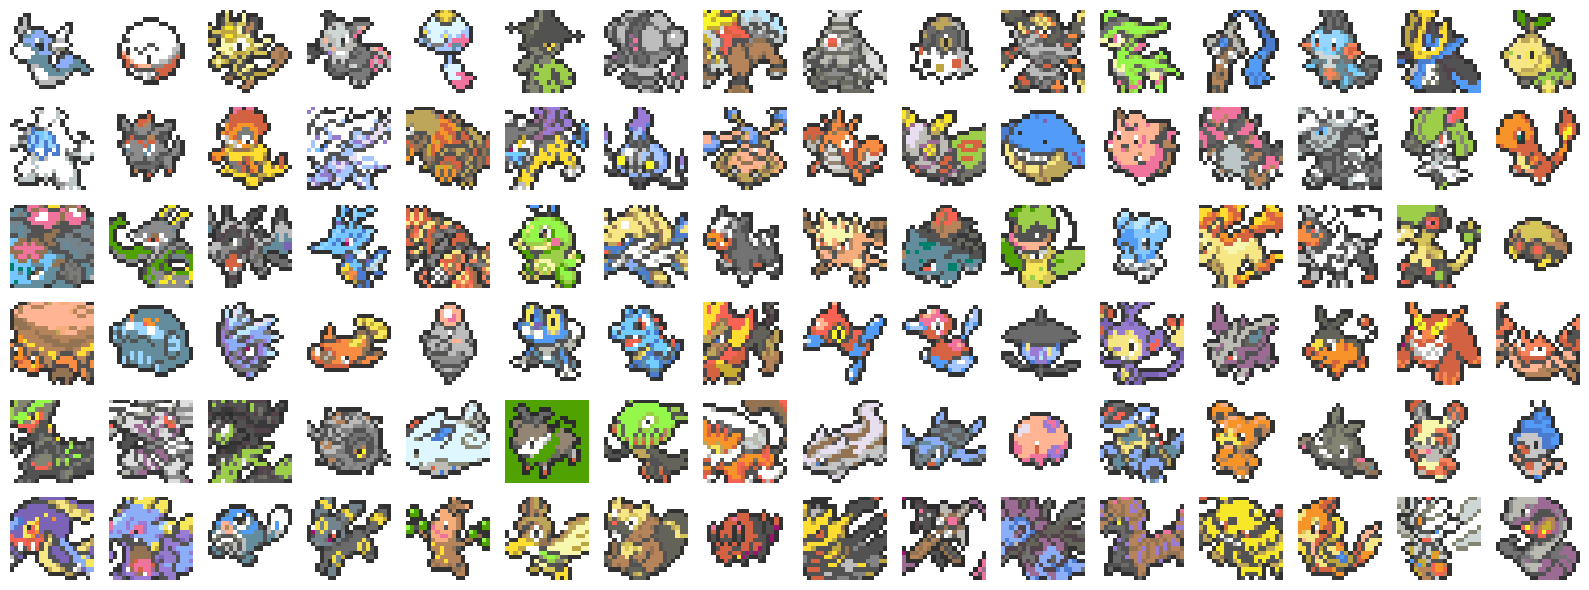

In [6]:
# Visualize train images
train_images = [pixel_to_image(data["pixel_color"], colormap) for data in pokemon_dataset["train"]]
show_images(train_images)

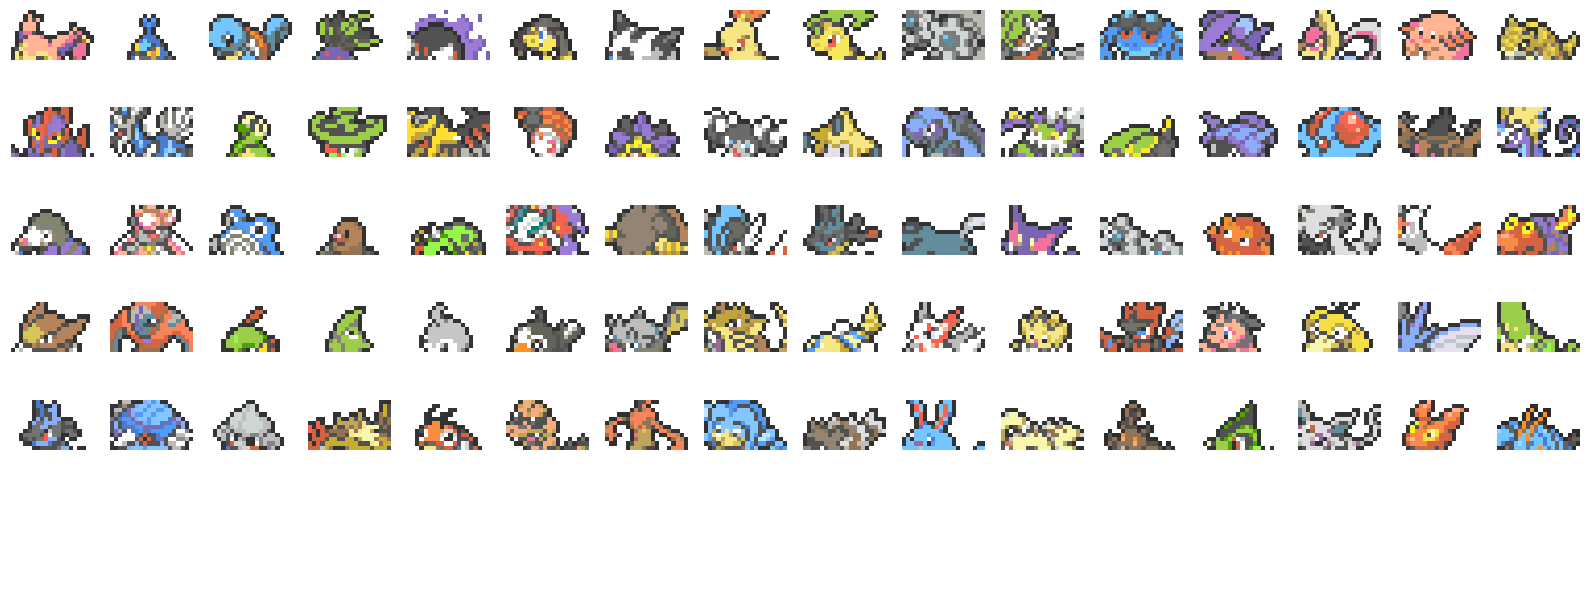

In [7]:
# Visualize test images
test_images = [pixel_to_image(data["pixel_color"], colormap) for data in pokemon_dataset["test"]]
show_images(test_images)

# Prepare Model

### Model Configuration
Here, we define the model configuration, including the architecture and key hyperparameters such as the number of attention heads, layers, embedding size, and more.
*   Hint 1: Adjust hyperparameters here for improved performance.
*   Hint 2: Experiment with different model architectures, such as Llama, Mistral, or Qwen, to enhance performance.
  * [LlamaConfig](https://huggingface.co/docs/transformers/model_doc/llama#transformers.LlamaConfig)
  * [MistralConfig](https://huggingface.co/docs/transformers/model_doc/mistral#transformers.MistralConfig)
  * [Qwen2Config](https://huggingface.co/docs/transformers/model_doc/qwen2#transformers.Qwen2Config)

The following sample code uses GPT-2.


In [8]:
# Define GPT-2 model configuration as a dictionary
gpt2_config = {
    "activation_function": "gelu_new",    # Activation function used in the model
    "architectures": ["GPT2LMHeadModel"],  # Specifies the model type
    "attn_pdrop": 0.1,            # Dropout rate for attention layers
    "embd_pdrop": 0.1,            # Dropout rate for embeddings
    "initializer_range": 0.02,        # Standard deviation for weight initialization
    "layer_norm_epsilon": 1e-05,       # Small constant to improve numerical stability in layer norm
    "model_type": "gpt2",           # Type of model
    "n_ctx": 128,               # Context size (maximum sequence length)
    "n_embd": 64,              # Embedding size
    "n_head": 2,               # Number of attention heads
    "n_layer": 2,              # Number of transformer layers
    "n_positions": 400,           # Maximum number of token positions
    "resid_pdrop": 0.1,           # Dropout rate for residual connections
    "vocab_size": num_classes,       # Number of unique tokens in vocabulary
    "pad_token_id": None,          # Padding token ID (None means no padding token)
    "eos_token_id": None,          # End-of-sequence token ID (None means not explicitly defined)
}

# Load GPT-2 model configuration from dictionary
config = GPT2Config.from_dict(gpt2_config)

### Load Model

In [9]:
# Load the model using the configuration defined above
model = AutoModelForCausalLM.from_config(config)

print(model)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable Parameters: {trainable_params:,}")

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(167, 64)
    (wpe): Embedding(400, 64)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=192, nx=64)
          (c_proj): Conv1D(nf=64, nx=64)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=256, nx=64)
          (c_proj): Conv1D(nf=64, nx=256)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=64, out_features=167, bias=False)
)
Trainable Parameters: 136,384


# Train and Inference

### Training Arguments
Here, we define the number of epochs for training, the learning rate, the optimizer, and the loss function.
*   Hint 3: Adjust the number of epochs and learning rate here to improve performance.

In [10]:
# Training Parameters
epochs = 50                                      # Number of training epochs
learning_rate = 1e-3                                 # Learning rate for optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
save_dir = "checkpoints"                               # Directory to save model checkpoints

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()                          # Loss function for classification tasks
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1) # AdamW optimizer with weight decay

### Save Model Function

In [11]:
def save_model(model: torch.nn.Module, optimizer: torch.optim.Optimizer, epoch: int, loss: float, save_dir: str, filename: str = "best_model.pth") -> None:
    """
    Saves the model state, optimizer state, current epoch, and loss to a specified directory.

    Args:
        model (torch.nn.Module): The PyTorch model to be saved.
        optimizer (torch.optim.Optimizer): The optimizer whose state will be saved.
        epoch (int): The current epoch number (used for checkpointing).
        loss (float): The current loss value to track model performance.
        save_dir (str): The directory where the model checkpoint will be saved.
        filename (str, optional): The name of the file to save the model. Defaults to "best_model.pth".

    Returns:
        None
    """
    # Construct the full path for saving the model checkpoint
    save_path = os.path.join(save_dir, filename)

    # Save the model, optimizer state, and additional metadata (epoch and loss)
    torch.save({
        'epoch': epoch + 1,                # Save epoch + 1 for easier tracking
        'model_state_dict': model.state_dict(),       # Save model weights
        'optimizer_state_dict': optimizer.state_dict(),  # Save optimizer state (important for resuming training)
        'loss': loss                     # Save the current loss value
    }, save_path)

    # Print a confirmation message indicating the model has been saved
    print(f"Model saved at {save_path} (Loss: {loss:.4f}, Epoch: {epoch + 1})")

### Train

We save the checkpoint with the lowest training loss since validation set reconstruction accuracy doesn't directly reflect the model's image generation quality.
*   Hint 4: Train a classifier to check if an image looks like a Pokémon or not.

Hint: A simple way to build negatives (no extra data)

Use train Pokémon images as positives, and use data augmentation to create negatives by destroying structure. For example, you can generate negatives (you should also explore other strategies and the final grade of this HW will be performance driven)
* random pixel permutation
* random noise tokens
* block shuffle
* ...

In [12]:
# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)
# Initialize best loss as positive infinity for comparison during model checkpointing
best_loss: float = float('inf')
# Move model to the appropriate device (GPU or CPU)
model.to(device)

# Training Loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Initialize the epoch loss

    # Iterate over training data batches
    for input_ids, labels in tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}/{epochs}"):
        input_ids, labels = input_ids.to(device), labels.to(device)  # Move data to the same device as the model

        # Forward pass through the model to get logits (output probabilities)
        outputs = model(input_ids=input_ids).logits.view(-1, config.vocab_size)
        labels = labels.view(-1)  # Flatten labels to match logits shape

        # Calculate loss using CrossEntropyLoss
        loss = criterion(outputs, labels)

        # Backpropagation and optimizer step
        optimizer.zero_grad()  # Reset gradients to zero
        loss.backward()     # Compute gradients
        optimizer.step()     # Update model weights

        # Accumulate the loss for the epoch
        epoch_loss += loss.item()

    # Compute average epoch loss
    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

    # Evaluation Loop (Validation)
    model.eval()      # Set the model to evaluation mode (disables dropout, etc.)
    total_accuracy = 0  # Initialize total accuracy
    num_batches = 0   # Initialize batch counter

    with torch.no_grad():  # Disable gradient calculation for validation
        # Iterate over validation data batches
        for inputs, labels in tqdm(dev_dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)  # Move validation data to device
            attention_mask = torch.ones_like(inputs)          # Attention mask to ensure valid token positions

            # Perform batch inference using the model
            generated_outputs = model.generate(inputs, attention_mask=attention_mask, max_length=400)

            # Extract the last 160 tokens from generated outputs and labels
            generated_outputs = generated_outputs[:, -160:]

            # Calculate accuracy for the batch
            accuracy = (generated_outputs == labels).float().mean().item()
            total_accuracy += accuracy
            num_batches += 1

    # Compute average reconstruction accuracy for the epoch
    avg_accuracy = total_accuracy / num_batches
    print(f"Epoch {epoch + 1}/{epochs}, Reconstruction Accuracy: {avg_accuracy:.4f}")

    # If the current epoch loss is better (lower) than the best loss, save the model
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss                   # Update best loss
        save_model(model, optimizer, epoch, best_loss, save_dir)  # Save the model with the best loss

Training Epoch 1/50: 100%|██████████| 40/40 [00:02<00:00, 16.09it/s]


Epoch 1/50, Loss: 3.8081


Evaluating: 100%|██████████| 5/5 [00:10<00:00,  2.06s/it]


Epoch 1/50, Reconstruction Accuracy: 0.4100
Model saved at checkpoints/best_model.pth (Loss: 3.8081, Epoch: 1)


Training Epoch 2/50: 100%|██████████| 40/40 [00:01<00:00, 26.52it/s]


...

Epoch 49/50, Reconstruction Accuracy: 0.3198
Model saved at checkpoints/best_model.pth (Loss: 1.4948, Epoch: 49)


Training Epoch 50/50: 100%|██████████| 40/40 [00:01<00:00, 27.07it/s]


Epoch 50/50, Loss: 1.4898


Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.74s/it]

Epoch 50/50, Reconstruction Accuracy: 0.3429
Model saved at checkpoints/best_model.pth (Loss: 1.4898, Epoch: 50)


### Inference

In [13]:
# Load the best model from the saved checkpoint
best_model_path = os.path.join(save_dir, "best_model.pth")              # Path to the best model checkpoint
checkpoint = torch.load(best_model_path, weights_only=True, map_location=device)  # Load checkpoint from the file
model.load_state_dict(checkpoint["model_state_dict"])                  # Load the model weights from checkpoint
model.eval()                                        # Set the model to evaluation mode (disables dropout, etc.)

# Testing Loop with Batch Inference
results: list = []  # List to store the generated sequences from the model

with torch.no_grad():  # Disable gradient calculations for inference
    # Iterate over test data in batches
    for inputs in tqdm(test_dataloader, desc="Generating Outputs"):
        inputs = inputs.to(device)         # Move model to the appropriate device (GPU or CPU)
        attention_mask = torch.ones_like(inputs)  # Attention mask (ensure valid token positions)

        # Generate predictions for the entire batch
        generated_outputs = model.generate(inputs, attention_mask=attention_mask, max_length=400)

        # Convert batch outputs to a list and append to results
        batch_results = generated_outputs.cpu().numpy().tolist()
        results.extend(batch_results)  # Extend the results list with batch results

# Save the results to a file
output_file: str = "reconstructed_results.txt"  # File to save the output sequences
with open(output_file, "w") as f:
    # Write each sequence to the file
    for seq in results:
        f.write(" ".join(map(str, seq)) + "\n")

print(f"Reconstructed results saved to {output_file}")  # Confirmation message

Generating Outputs: 100%|██████████| 5/5 [00:08<00:00,  1.74s/it]

Reconstructed results saved to reconstructed_results.txt


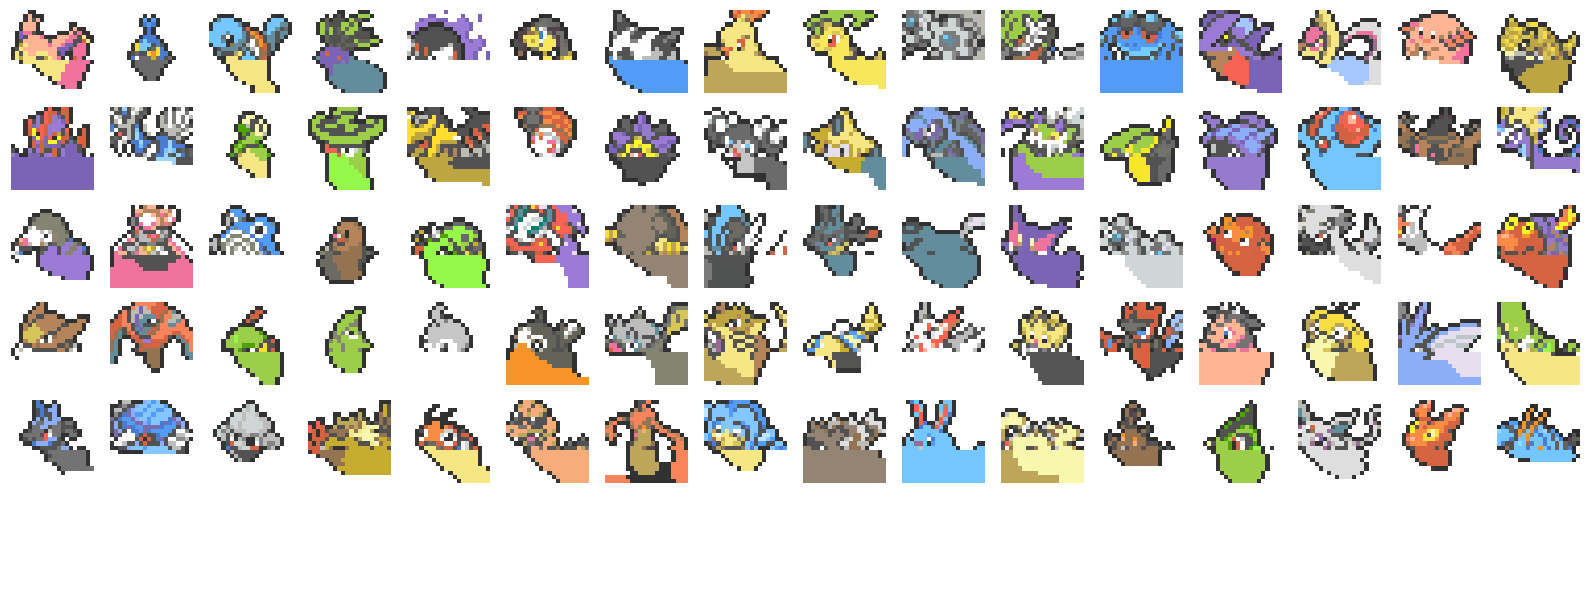

In [14]:
# Visualize generated test images
predicted_images = [pixel_to_image(sequence, colormap) for sequence in results]
show_images(predicted_images)

###Evaluate your generated results
 * 1. Compute FID between real and generated images. Hint: For convenience, you can first convert everything to RGB tensors. FID is available in multiple packages such as torchmetrics.image.fid.
 * 2. Use your trained classifier to calculate the PDR (Poken Detection Rate), (I am changing from the false dicovery rate to PDR).



In [15]:
# !uv add torchmetrics[image] -q

import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance

# ============================================
# Part 1: Compute FID using torchmetrics
# ============================================

def images_to_tensor(images, size=299):
    """Convert PIL images to uint8 tensor (N, 3, H, W) resized for InceptionV3."""
    tensors = []
    for img in images:
        arr = torch.tensor(np.array(img, dtype=np.float32)).permute(2, 0, 1).unsqueeze(0)
        resized = F.interpolate(arr, size=(size, size), mode='bilinear', align_corners=False)
        tensors.append(resized.clamp(0, 255).to(torch.uint8))
    return torch.cat(tensors, dim=0)

# Convert real and generated images to tensors for FID
real_tensors = images_to_tensor(train_images)
gen_tensors = images_to_tensor(predicted_images)

# Compute FID using InceptionV3 features
fid_metric = FrechetInceptionDistance(feature=2048, normalize=False)
fid_metric.update(real_tensors, real=True)
fid_metric.update(gen_tensors, real=False)
fid_score = fid_metric.compute().item()
print(f"FID Score: {fid_score:.4f}")

# ============================================
# Part 2: Train classifier and compute PDR
# ============================================

class PokemonClassifier(nn.Module):
    """CNN classifier for Pokemon vs non-Pokemon images."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

def generate_negatives(real_images):
    """Generate negatives by destroying image structure: pixel permutation, block shuffle, random noise."""
    negatives = []
    for i, img in enumerate(real_images):
        arr = np.array(img, dtype=np.float32).transpose(2, 0, 1) / 255.0  # (3, 20, 20)

        strategy = i % 3
        if strategy == 0:
            # Random pixel permutation -- shuffle all pixel positions
            flat = arr.reshape(3, -1)
            perm_idx = np.random.permutation(flat.shape[1])
            neg = flat[:, perm_idx].reshape(3, 20, 20)
        elif strategy == 1:
            # Block shuffle -- divide into 5x5 blocks and shuffle them
            blocks = []
            for r in range(0, 20, 5):
                for c in range(0, 20, 5):
                    blocks.append(arr[:, r:r+5, c:c+5].copy())
            np.random.shuffle(blocks)
            neg = np.zeros_like(arr)
            idx = 0
            for r in range(0, 20, 5):
                for c in range(0, 20, 5):
                    neg[:, r:r+5, c:c+5] = blocks[idx]
                    idx += 1
        else:
            # Random noise tokens
            neg = np.random.rand(3, 20, 20).astype(np.float32)

        negatives.append(neg)
    return negatives

# Build balanced training data: real Pokemon (1) vs structure-destroyed negatives (0)
pos_data = [np.array(img, dtype=np.float32).transpose(2, 0, 1) / 255.0 for img in train_images]
neg_data = generate_negatives(train_images)

cls_x = torch.tensor(np.array(pos_data + neg_data))
cls_y = torch.tensor([1] * len(pos_data) + [0] * len(neg_data))

cls_loader = DataLoader(
    torch.utils.data.TensorDataset(cls_x, cls_y), batch_size=32, shuffle=True
)

classifier = PokemonClassifier().to(device)
cls_opt = optim.Adam(classifier.parameters(), lr=1e-3)
cls_loss_fn = nn.CrossEntropyLoss()

print("\nTraining Pokemon classifier...")
classifier.train()
for ep in range(20):
    correct, total = 0, 0
    for bx, by in cls_loader:
        bx, by = bx.to(device), by.to(device)
        cls_opt.zero_grad()
        out = classifier(bx)
        cls_loss_fn(out, by).backward()
        cls_opt.step()
        correct += (out.argmax(1) == by).sum().item()
        total += by.size(0)
    if (ep + 1) % 5 == 0:
        print(f"  Epoch {ep+1}/20 | Acc: {correct/total:.4f}")

# Classify generated images and compute PDR (Pokemon Detection Rate)
classifier.eval()
pokemon_count = 0
with torch.no_grad():
    for img in predicted_images:
        arr = np.array(img, dtype=np.float32).transpose(2, 0, 1) / 255.0
        t = torch.tensor(arr).unsqueeze(0).to(device)
        if classifier(t).argmax(1).item() == 1:
            pokemon_count += 1

pdr = pokemon_count / len(predicted_images)
print(f"\nPDR (Pokemon Detection Rate) Evaluation:")
print(f"  Classified as Pokemon: {pokemon_count}/{len(predicted_images)}")
print(f"  PDR: {pdr:.4f}")

FID Score: 81.4228

Training Pokemon classifier...
  Epoch 5/20 | Acc: 0.9604
  Epoch 10/20 | Acc: 0.9842
  Epoch 15/20 | Acc: 0.9976
  Epoch 20/20 | Acc: 0.9992

PDR (Pokemon Detection Rate) Evaluation:
  Classified as Pokemon: 78/80
  PDR: 0.9750


### Summarize your results

**Approach**: Decoder-only transformer (GPT-2) trained on color-indexed Pokemon pixel sequences (20x20 images, 400 pixels each) using next-token prediction. At inference, given the first 240 pixels (60%), the model autoregressively generates the remaining 160 pixels (40%).

**Model Configuration**:
| Parameter | Value |
|---|---|
| Architecture | GPT-2 (decoder-only) |
| Layers | 2 |
| Attention Heads | 2 |
| Embedding Dim | 64 |
| Max Positions | 400 |
| Trainable Parameters | 136,384 |
| Epochs | 50 |
| Learning Rate | 1e-3 |
| Optimizer | AdamW (weight_decay=0.1) |
| Loss Function | CrossEntropyLoss |
| Batch Size | 16 |

**Evaluation Results**:
| Metric | Value | Interpretation |
|---|---|---|
| FID (InceptionV3) | 81.4228 | Frechet Inception Distance between real and generated images using InceptionV3 features. Lower is better. |
| PDR (Pokemon Detection Rate) | 0.9750 (78/80) | Proportion of generated images classified as Pokemon by the trained CNN classifier. Higher is better. |

**Classifier Details**:
- Trained for 20 epochs, reaching 99.92% accuracy on the training set
- Negative generation strategies (balanced, 1/3 each):
  - Random pixel permutation: shuffles all pixel positions to destroy spatial structure
  - Block shuffle: divides 20x20 image into 5x5 blocks and randomly reorders them
  - Random noise: generates uniform random pixel values

**Analysis**:
- FID of 81.42 is computed using `torchmetrics.image.fid.FrechetInceptionDistance` with InceptionV3 features (2048-dim), after resizing 20x20 images to 299x299
- PDR of 97.5% indicates that 78 out of 80 generated images retain enough Pokemon-like structure to be recognized by the classifier. Only 2 generated images were rejected.
- The use of stronger negatives (pixel permutation, block shuffle) alongside random noise makes the classifier more discriminative than one trained only on random noise.

**Potential Improvements**:
- Increase model capacity (more layers, attention heads, larger embeddings)
- Experiment with alternative architectures (LLaMA, Mistral, Qwen2)
- Tune learning rate schedule and number of training epochs
- Add more aggressive negative strategies for a more discriminative classifier